<div align="center">

![Course](https://img.shields.io/badge/Course-Advanced%20Data%20Science%20Lab-blue?style=for-the-badge&logo=python&logoColor=white)
![Code](https://img.shields.io/badge/Code-MCA33PE21-informational?style=for-the-badge)
![Assignment](https://img.shields.io/badge/Assignment-01-success?style=for-the-badge)

---

# Advanced Data Science Lab [MCA33PE21]
## Experiential Learning Assignment - 01
### Apply Pandas, NumPy, Matplotlib, and Seaborn to solve real-world data analysis and visualization problems

---
<br>

| Field | Details |
|---|---|
| **Academic Year** | **2026-2027** |
| **Class / Division** | **SYMCA (Semester-I)** |
| **PRN** |**125M1H064** |
| **Student Name** | **Manthan Vijay Sankpal**|
| **Submission Date** | **11th of July 2026** |
</div>

---

### Question 1 — Analyze Customer Purchase Patterns

Given a CSV file containing customer transactions (`customer_id`, `purchase_amount`, `date`), use **Pandas** to calculate the **average monthly spending per customer**.

**Tasks:**
- Create a sample transaction dataset (minimum 20 rows).
- Parse date strings into datetime objects.
- Extract month from the date column.
- Group by `customer_id` and month, then compute the average spending.

In [1]:
# Question 1 — Analyze Customer Purchase Patterns
# Write your code below

import pandas as pd
import numpy as np

# Create sample transaction dataset
np.random.seed(42)
n_transactions = 30

data = {
    "customer_id": np.random.choice(["C001", "C002", "C003", "C004", "C005"], n_transactions),
    "purchase_amount": np.round(np.random.uniform(100, 5000, n_transactions), 2),
    "date": pd.date_range(start="2025-01-01", periods=n_transactions, freq="10D")
}

df_transactions = pd.DataFrame(data)

print("=" * 60)
print("       CUSTOMER TRANSACTION DATA")
print("=" * 60)
print(df_transactions.to_string(index=False))

# Extract month from date
df_transactions["month"] = df_transactions["date"].dt.to_period("M")

# Group by customer_id and month -> average monthly spending
avg_monthly_spending = (
    df_transactions
    .groupby(["customer_id", "month"])["purchase_amount"]
    .mean()
    .round(2)
    .reset_index()
    .rename(columns={"purchase_amount": "avg_monthly_spending"})
)

print("\n" + "=" * 60)
print("  AVERAGE MONTHLY SPENDING PER CUSTOMER")
print("=" * 60)
print(avg_monthly_spending.to_string(index=False))

# Expected Output: DataFrame showing average monthly spending per customer

       CUSTOMER TRANSACTION DATA
customer_id  purchase_amount       date
       C004          1895.17 2025-01-01
       C005          2334.74 2025-01-11
       C003          3947.36 2025-01-21
       C005          1078.40 2025-01-31
       C005          2619.75 2025-02-10
       C002          3002.83 2025-02-20
       C003           327.61 2025-03-02
       C003          3076.97 2025-03-12
       C003           935.57 2025-03-22
       C005           418.75 2025-04-01
       C004          4749.54 2025-04-11
       C003          4831.60 2025-04-21
       C005          4061.15 2025-05-01
       C002          1592.61 2025-05-11
       C004           578.59 2025-05-21
       C002          3452.74 2025-05-31
       C004          2256.75 2025-06-10
       C005           697.99 2025-06-20
       C001          2526.37 2025-06-30
       C004           268.50 2025-07-10
       C002          4555.67 2025-07-20
       C005          1368.02 2025-07-30
       C004          3346.36 2025-08-09
       

### Question 2 — Identify Missing Values and Impute

Using a dataset with missing values (e.g., `age`, `salary`), use **Pandas** and **NumPy** to identify missing values and fill them with the **column mean**.

**Tasks:**
- Create a dataset with intentional missing values (`NaN`).
- Identify missing values using `isnull()` / `isna()`.
- Display the count of missing values per column.
- Fill missing values with the column mean using `fillna()`.
- Verify that no missing values remain.

In [2]:
# Question 2 — Identify Missing Values and Impute
# Write your code below

import pandas as pd
import numpy as np

# Create dataset with intentional missing values
data = {
    "name":   ["Manthan", "Shreya", "Shreyash", "MJ", "Vaibhav", "Riya", "Karan", "Sneha", "Rohan", "Priya"],
    "age":    [21, np.nan, 20, 22, np.nan, 23, 21, np.nan, 24, 20],
    "salary": [35000, 42000, np.nan, 55000, 48000, np.nan, 38000, 60000, np.nan, 45000]
}

df = pd.DataFrame(data)

print("=" * 60)
print("       ORIGINAL DATASET (with missing values)")
print("=" * 60)
print(df)

# Identify missing values
print("\n" + "=" * 60)
print("       MISSING VALUE IDENTIFICATION")
print("=" * 60)
print("\nMissing values per column:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

# Fill missing values with column mean
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    col_mean = df[col].mean()
    print(f"\nMean of '{col}': {col_mean:.2f}")
    df[col] = df[col].fillna(col_mean)

print("\n" + "=" * 60)
print("       DATASET AFTER IMPUTATION")
print("=" * 60)
print(df)

# Verify no missing values remain
print("\nMissing values after imputation:")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())

# Expected Output: DataFrame with no missing values after imputation

       ORIGINAL DATASET (with missing values)
       name   age   salary
0   Manthan  21.0  35000.0
1    Shreya   NaN  42000.0
2  Shreyash  20.0      NaN
3        MJ  22.0  55000.0
4   Vaibhav   NaN  48000.0
5      Riya  23.0      NaN
6     Karan  21.0  38000.0
7     Sneha   NaN  60000.0
8     Rohan  24.0      NaN
9     Priya  20.0  45000.0

       MISSING VALUE IDENTIFICATION

Missing values per column:
name      0
age       3
salary    3
dtype: int64

Total missing values: 6

Mean of 'age': 21.57

Mean of 'salary': 46142.86

       DATASET AFTER IMPUTATION
       name        age        salary
0   Manthan  21.000000  35000.000000
1    Shreya  21.571429  42000.000000
2  Shreyash  20.000000  46142.857143
3        MJ  22.000000  55000.000000
4   Vaibhav  21.571429  48000.000000
5      Riya  23.000000  46142.857143
6     Karan  21.000000  38000.000000
7     Sneha  21.571429  60000.000000
8     Rohan  24.000000  46142.857143
9     Priya  20.000000  45000.000000

Missing values after imputa

### Question 3 — Filter and Sort Employee Records

Given employee data (`name`, `department`, `salary`), use **Pandas** to filter employees in the **"IT" department** earning above **60K** and sort them by salary.

**Tasks:**
- Create an employee DataFrame with at least 10 rows.
- Filter rows where `department == "IT"` and `salary > 60000`.
- Sort the filtered results by salary in descending order.
- Display both the original and filtered DataFrames.

In [3]:
# Question 3 — Filter and Sort Employee Records
# Write your code below

import pandas as pd

# Create employee dataset
employee_data = {
    "name":       ["Manthan", "Shreya", "Shreyash", "MJ", "Vaibhav",
                   "Riya", "Karan", "Sneha", "Rohan", "Priya",
                   "Amit", "Neha"],
    "department": ["IT", "HR", "IT", "Finance", "IT",
                   "HR", "IT", "IT", "Finance", "IT",
                   "IT", "HR"],
    "salary":     [75000, 52000, 68000, 85000, 92000,
                   48000, 55000, 78000, 62000, 43000,
                   95000, 58000]
}

df_employees = pd.DataFrame(employee_data)

print("=" * 60)
print("           ALL EMPLOYEE RECORDS")
print("=" * 60)
print(df_employees.to_string(index=False))

# Filter: IT department AND salary > 60K
it_above_60k = df_employees[
    (df_employees["department"] == "IT") &
    (df_employees["salary"] > 60000)
]

# Sort by salary (descending)
it_above_60k_sorted = it_above_60k.sort_values(by="salary", ascending=False)

print("\n" + "=" * 60)
print("  IT EMPLOYEES EARNING ABOVE 60K (sorted by salary desc)")
print("=" * 60)
print(it_above_60k_sorted.to_string(index=False))

print(f"\nTotal matching employees: {len(it_above_60k_sorted)}")

# Expected Output: Filtered & sorted DataFrame of IT employees earning > 60K

           ALL EMPLOYEE RECORDS
    name department  salary
 Manthan         IT   75000
  Shreya         HR   52000
Shreyash         IT   68000
      MJ    Finance   85000
 Vaibhav         IT   92000
    Riya         HR   48000
   Karan         IT   55000
   Sneha         IT   78000
   Rohan    Finance   62000
   Priya         IT   43000
    Amit         IT   95000
    Neha         HR   58000

  IT EMPLOYEES EARNING ABOVE 60K (sorted by salary desc)
    name department  salary
    Amit         IT   95000
 Vaibhav         IT   92000
   Sneha         IT   78000
 Manthan         IT   75000
Shreyash         IT   68000

Total matching employees: 5


### Question 4 — Calculate Statistical Metrics for Stock Data

Using **NumPy** and **Pandas**, calculate the **mean**, **median**, and **standard deviation** of daily stock prices from a dataset.

**Tasks:**
- Create a stock price dataset with at least 30 trading days.
- Calculate mean, median, and standard deviation using both NumPy and Pandas.
- Display the results clearly.

In [4]:
# Question 4 — Calculate Statistical Metrics for Stock Data
# Write your code below

import pandas as pd
import numpy as np

# Generate sample stock data (simulating realistic prices)
np.random.seed(42)
n_days = 30

dates = pd.date_range(start="2025-06-01", periods=n_days, freq="B")  # Business days

# Simulate stock price with random walk
base_price = 150.0
daily_returns = np.random.normal(0, 2, n_days)  # mean=0, std=2
prices = base_price + np.cumsum(daily_returns)
prices = np.round(prices, 2)

df_stock = pd.DataFrame({
    "date": dates,
    "close_price": prices
})

print("=" * 60)
print("          DAILY STOCK PRICE DATA")
print("=" * 60)
print(df_stock.to_string(index=False))

# Statistical metrics using NumPy
np_mean   = np.mean(prices)
np_median = np.median(prices)
np_std    = np.std(prices)

# Statistical metrics using Pandas
pd_mean   = df_stock["close_price"].mean()
pd_median = df_stock["close_price"].median()
pd_std    = df_stock["close_price"].std(ddof=0)  # Population std to match NumPy

print("\n" + "=" * 60)
print("     STATISTICAL METRICS — STOCK PRICES")
print("=" * 60)

print(f"\n{'Metric':<25} {'NumPy':>12} {'Pandas':>12}")
print("-" * 50)
print(f"{'Mean':25s} {np_mean:12.2f} {pd_mean:12.2f}")
print(f"{'Median':25s} {np_median:12.2f} {pd_median:12.2f}")
print(f"{'Standard Deviation':25s} {np_std:12.2f} {pd_std:12.2f}")

# Expected Output: Mean, Median, Std Dev of stock prices from both NumPy and Pandas

          DAILY STOCK PRICE DATA
      date  close_price
2025-06-02       150.99
2025-06-03       150.72
2025-06-04       152.01
2025-06-05       155.06
2025-06-06       154.59
2025-06-09       154.12
2025-06-10       157.28
2025-06-11       158.82
2025-06-12       157.88
2025-06-13       158.96
2025-06-16       158.03
2025-06-17       157.10
2025-06-18       157.59
2025-06-19       153.76
2025-06-20       150.31
2025-06-23       149.19
2025-06-24       147.16
2025-06-25       147.79
2025-06-26       145.97
2025-06-27       143.15
2025-06-30       146.08
2025-07-01       145.63
2025-07-02       145.76
2025-07-03       142.91
2025-07-04       141.82
2025-07-07       142.05
2025-07-08       139.74
2025-07-09       140.50
2025-07-10       139.29
2025-07-11       138.71

     STATISTICAL METRICS — STOCK PRICES

Metric                           NumPy       Pandas
--------------------------------------------------
Mean                            149.43       149.43
Median                    

### Question 5 — Create a Pivot Table for Sales Analysis

From a sales dataset (`region`, `product`, `sales`), use **Pandas** to create a **pivot table** showing **total sales per region per product**.

**Tasks:**
- Create a sales dataset with at least 20 rows.
- Use `pd.pivot_table()` to create the pivot table.
- Show total sales broken down by region (rows) and product (columns).
- Add row and column totals using `margins=True`.

In [5]:
# Question 5 — Create a Pivot Table for Sales Analysis
# Write your code below

import pandas as pd
import numpy as np

# Create sample sales dataset
np.random.seed(42)

regions  = ["North", "South", "East", "West"]
products = ["Laptop", "Phone", "Tablet", "Headphones"]

n_records = 24
sales_data = {
    "region":  np.random.choice(regions, n_records),
    "product": np.random.choice(products, n_records),
    "sales":   np.random.randint(5000, 50000, n_records)
}

df_sales = pd.DataFrame(sales_data)

print("=" * 60)
print("               RAW SALES DATA")
print("=" * 60)
print(df_sales.to_string(index=False))

# Create pivot table: total sales per region per product
pivot = pd.pivot_table(
    df_sales,
    values="sales",
    index="region",
    columns="product",
    aggfunc="sum",
    fill_value=0,
    margins=True,
    margins_name="TOTAL"
)

print("\n" + "=" * 60)
print("  PIVOT TABLE — TOTAL SALES PER REGION PER PRODUCT")
print("=" * 60)
print(pivot)

# Expected Output: Pivot table with total sales by region and product

               RAW SALES DATA
region    product  sales
  East Headphones   5189
  West      Phone  24118
 North      Phone  40773
  East      Phone   6899
  East Headphones   6267
  West Headphones  36551
 North     Laptop  16394
 North     Laptop   8556
  East Headphones   8890
 South      Phone  46606
  East      Phone  35740
  East     Laptop  19502
  East Headphones  26777
  East     Laptop  15627
  West     Laptop  13792
 North     Tablet  48323
  West     Tablet  48021
  West     Tablet  13433
  West      Phone  48001
  East Headphones  16016
 South Headphones  28897
 North Headphones   7612
 South Headphones  28483
  West     Tablet  22159

  PIVOT TABLE — TOTAL SALES PER REGION PER PRODUCT
product  Headphones  Laptop   Phone  Tablet   TOTAL
region                                             
East          63139   35129   42639       0  140907
North          7612   24950   40773   48323  121658
South         57380       0   46606       0  103986
West          36551   13792   721

### Question 6 — Plot Monthly Sales Using Matplotlib

From a dataset with `month` and `sales`, use **Matplotlib** to create a **line chart** showing monthly sales trends.

**Tasks:**
- Create a dataset with 12 months of sales data.
- Plot a line chart with proper axis labels, title, and grid.
- Add data point markers and annotate peak sales.

   MONTHLY SALES DATA
month  sales
  Jan  12000
  Feb  15000
  Mar  18000
  Apr  14000
  May  22000
  Jun  25000
  Jul  28000
  Aug  30000
  Sep  26000
  Oct  20000
  Nov  32000
  Dec  35000


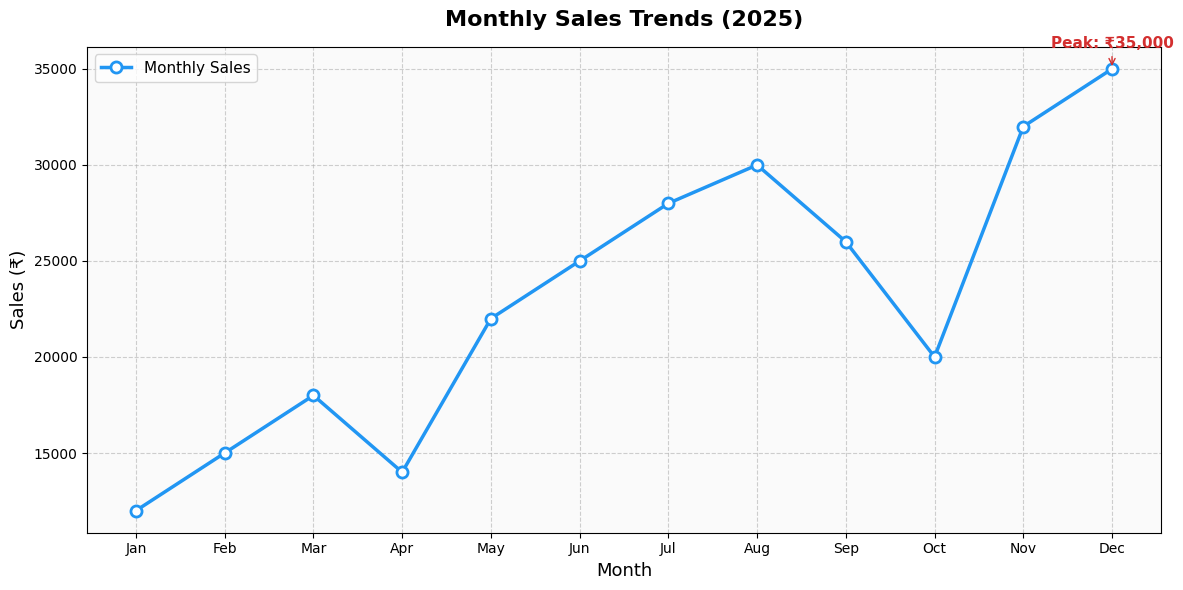

In [6]:
# Question 6 — Plot Monthly Sales Using Matplotlib
# Write your code below

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Create monthly sales data
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
sales  = [12000, 15000, 18000, 14000, 22000, 25000,
          28000, 30000, 26000, 20000, 32000, 35000]

df_monthly = pd.DataFrame({"month": months, "sales": sales})

print("=" * 40)
print("   MONTHLY SALES DATA")
print("=" * 40)
print(df_monthly.to_string(index=False))

# Line chart
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(months, sales, color="#2196F3", linewidth=2.5,
        marker="o", markersize=8, markerfacecolor="white",
        markeredgewidth=2, markeredgecolor="#2196F3",
        label="Monthly Sales")

# Annotate peak sales
peak_idx = np.argmax(sales)
ax.annotate(f"Peak: ₹{sales[peak_idx]:,}",
            xy=(months[peak_idx], sales[peak_idx]),
            xytext=(0, 15), textcoords="offset points",
            ha="center", fontsize=11, fontweight="bold",
            color="#D32F2F",
            arrowprops=dict(arrowstyle="->", color="#D32F2F"))

ax.set_title("Monthly Sales Trends (2025)", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Month", fontsize=13)
ax.set_ylabel("Sales (₹)", fontsize=13)
ax.legend(fontsize=11, loc="upper left")
ax.grid(True, linestyle="--", alpha=0.6)
ax.set_facecolor("#FAFAFA")

plt.tight_layout()
plt.show()

# Expected Output: Line chart with monthly sales trend

### Question 7 — Compare Category Sales with Bar Chart

Create a **bar chart** using **Matplotlib** to compare total sales for different product categories.

**Tasks:**
- Create a dataset with at least 5 product categories and their total sales.
- Plot a bar chart with distinct colors per category.
- Add value labels on top of each bar.
- Include title, axis labels, and grid.

   CATEGORY-WISE SALES DATA
   category  total_sales
Electronics       125000
   Clothing        89000
  Groceries       110000
      Books        45000
     Sports        67000
 Home Decor        78000


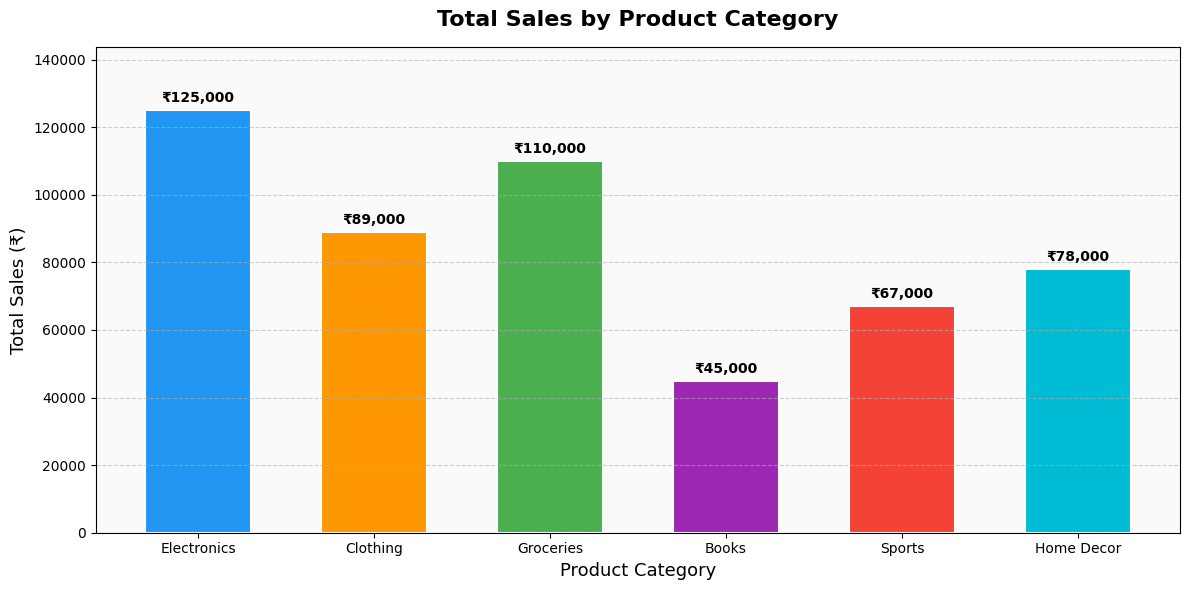

In [7]:
# Question 7 — Compare Category Sales with Bar Chart
# Write your code below

import matplotlib.pyplot as plt
import pandas as pd

# Create category sales data
categories = ["Electronics", "Clothing", "Groceries", "Books", "Sports", "Home Decor"]
total_sales = [125000, 89000, 110000, 45000, 67000, 78000]

df_category = pd.DataFrame({"category": categories, "total_sales": total_sales})

print("=" * 40)
print("   CATEGORY-WISE SALES DATA")
print("=" * 40)
print(df_category.to_string(index=False))

# Bar chart
colors = ["#2196F3", "#FF9800", "#4CAF50", "#9C27B0", "#F44336", "#00BCD4"]

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(categories, total_sales, color=colors, edgecolor="white",
              linewidth=1.5, width=0.6)

# Add value labels on top of bars
for bar, val in zip(bars, total_sales):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1500,
            f"₹{val:,}", ha="center", va="bottom",
            fontsize=10, fontweight="bold")

ax.set_title("Total Sales by Product Category", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Product Category", fontsize=13)
ax.set_ylabel("Total Sales (₹)", fontsize=13)
ax.grid(axis="y", linestyle="--", alpha=0.6)
ax.set_facecolor("#FAFAFA")
ax.set_ylim(0, max(total_sales) * 1.15)

plt.tight_layout()
plt.show()

# Expected Output: Bar chart comparing total sales across product categories

### Question 8 — Visualize Correlation Using Heatmap (Seaborn)

Given a dataset with multiple numeric columns, use **Seaborn** to draw a **heatmap** of the correlation matrix.

**Tasks:**
- Create a dataset with at least 5 numeric columns and 20+ rows.
- Compute the correlation matrix using `.corr()`.
- Display the heatmap with annotations, a color bar, and proper formatting.

       STUDENT PERFORMANCE DATASET (first 10 rows)
 study_hours  sleep_hours  attendance  assignments  exam_score  stress_level
        5.12         9.82       51.57            0       46.93          2.59
       11.46         8.65       81.82            0       36.52          9.46
        9.05         9.64       65.72            2       92.81          9.59
        7.59         9.37       75.43            1       93.03          9.23
        2.72         7.59       95.38            4       74.32          4.33
        2.72         9.53       62.46            9       53.73          1.14
        1.64         4.53       70.52            5       54.44          9.35
       10.53         5.18       87.78            6       80.82          4.85
        7.61         4.27       61.44            3       92.80          9.70
        8.79         5.95       53.85            6       92.10          9.67

              CORRELATION MATRIX
              study_hours  sleep_hours  attendance  assignments  exa

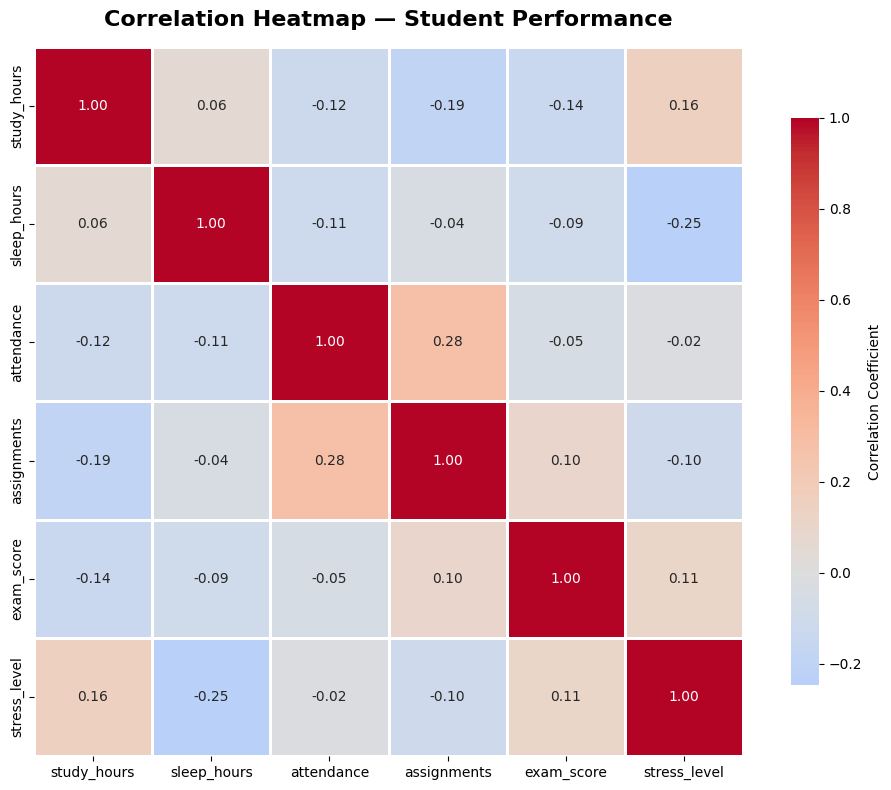

In [8]:
# Question 8 — Visualize Correlation Using Heatmap (Seaborn)
# Write your code below

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Create multi-variable dataset
np.random.seed(42)
n = 50

data = {
    "study_hours":   np.random.uniform(1, 12, n),
    "sleep_hours":   np.random.uniform(4, 10, n),
    "attendance":    np.random.uniform(50, 100, n),
    "assignments":   np.random.randint(0, 10, n),
    "exam_score":    np.random.uniform(30, 100, n),
    "stress_level":  np.random.uniform(1, 10, n)
}

df = pd.DataFrame(data).round(2)

print("=" * 60)
print("       STUDENT PERFORMANCE DATASET (first 10 rows)")
print("=" * 60)
print(df.head(10).to_string(index=False))

# Compute correlation matrix
corr_matrix = df.corr().round(3)

print("\n" + "=" * 60)
print("              CORRELATION MATRIX")
print("=" * 60)
print(corr_matrix)

# Heatmap
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=1,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"},
    ax=ax
)

ax.set_title("Correlation Heatmap — Student Performance",
             fontsize=16, fontweight="bold", pad=15)

plt.tight_layout()
plt.show()

# Expected Output: Heatmap of the correlation matrix

### Question 9 — Visualize Age Distribution Using Histogram

Using a dataset with an `age` column, plot a **histogram** with **Seaborn** to show the age distribution.

**Tasks:**
- Create a dataset with at least 100 age values.
- Plot a histogram using `sns.histplot()` with a KDE (kernel density estimate) overlay.
- Add title, axis labels, and customize bin count and color.

    AGE DATA — SUMMARY STATISTICS
          age
count  200.00
mean    34.34
std     10.57
min     18.00
25%     26.00
50%     34.50
75%     40.25
max     67.00


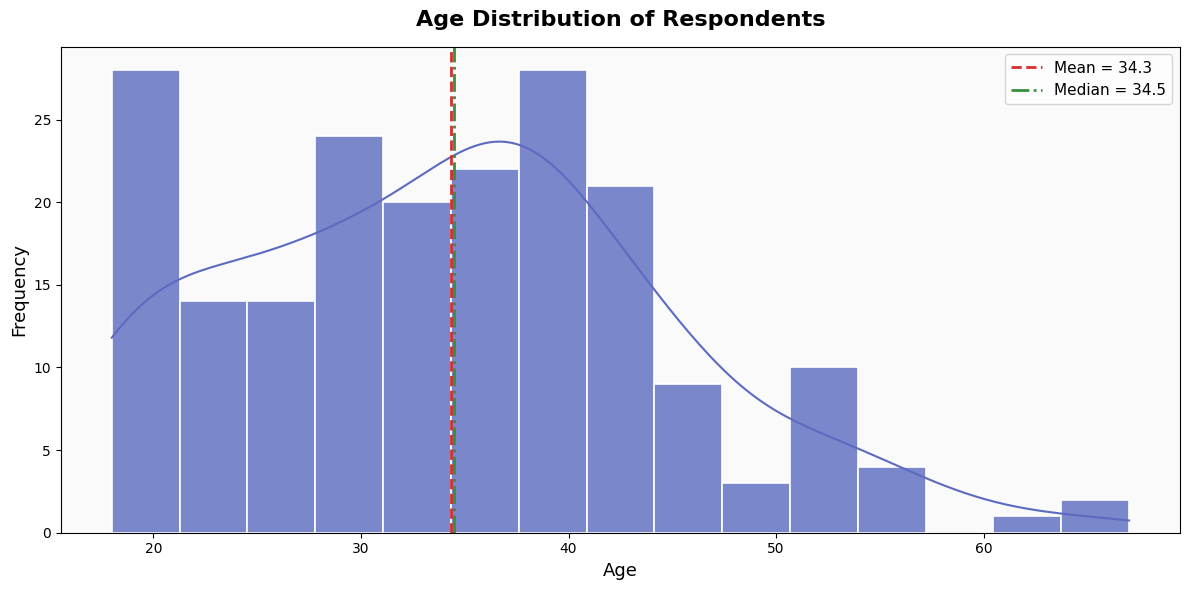

In [9]:
# Question 9 — Visualize Age Distribution Using Histogram
# Write your code below

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Generate age data (normally distributed around 35)
np.random.seed(42)
ages = np.random.normal(loc=35, scale=12, size=200)
ages = np.clip(ages, 18, 70).astype(int)  # Restrict to realistic range

df_age = pd.DataFrame({"age": ages})

print("=" * 50)
print("    AGE DATA — SUMMARY STATISTICS")
print("=" * 50)
print(df_age.describe().round(2))

# Histogram with KDE overlay
fig, ax = plt.subplots(figsize=(12, 6))

sns.histplot(
    data=df_age,
    x="age",
    bins=15,
    kde=True,
    color="#5C6BC0",
    edgecolor="white",
    linewidth=1.2,
    alpha=0.8,
    ax=ax
)

# Add mean and median lines
mean_age = df_age["age"].mean()
median_age = df_age["age"].median()

ax.axvline(mean_age, color="#D32F2F", linestyle="--", linewidth=2,
           label=f"Mean = {mean_age:.1f}")
ax.axvline(median_age, color="#388E3C", linestyle="-.", linewidth=2,
           label=f"Median = {median_age:.1f}")

ax.set_title("Age Distribution of Respondents", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Age", fontsize=13)
ax.set_ylabel("Frequency", fontsize=13)
ax.legend(fontsize=11)
ax.set_facecolor("#FAFAFA")

plt.tight_layout()
plt.show()

# Expected Output: Histogram showing age distribution with KDE curve

### Question 10 — Scatter Plot to Show Relationship Between Two Variables

Use **Seaborn** to create a **scatter plot** showing the relationship between **advertising budget** and **sales**.

**Tasks:**
- Create a dataset with `advertising_budget` and `sales` (at least 30 data points).
- Plot a scatter plot using `sns.scatterplot()` or `sns.regplot()` with a regression line.
- Use different colors/markers if multiple categories exist.
- Add title, axis labels, and a legend.

   ADVERTISING BUDGET vs SALES (first 15 rows)
 advertising_budget  sales channel
             143.64  24.45      TV
             287.68  40.04      TV
             233.00  32.61      TV
             199.66  28.06      TV
              89.00  11.24      TV
              89.00  13.52      TV
              64.52  11.36      TV
             266.54  40.16      TV
             200.28  30.06      TV
             227.02  26.95      TV
              55.15  12.59      TV
             292.48  38.94      TV
             258.11  33.94      TV
             103.08  19.21      TV
              95.46  19.55      TV

         SUMMARY BY CHANNEL
        advertising_budget                                               \
                     count    mean    std    min    25%     50%     75%   
channel                                                                   
Digital               50.0  106.84  51.94  21.25  64.01  102.49  149.94   
Print                 50.0   93.56  40.05  12.16  60.70  100.68 

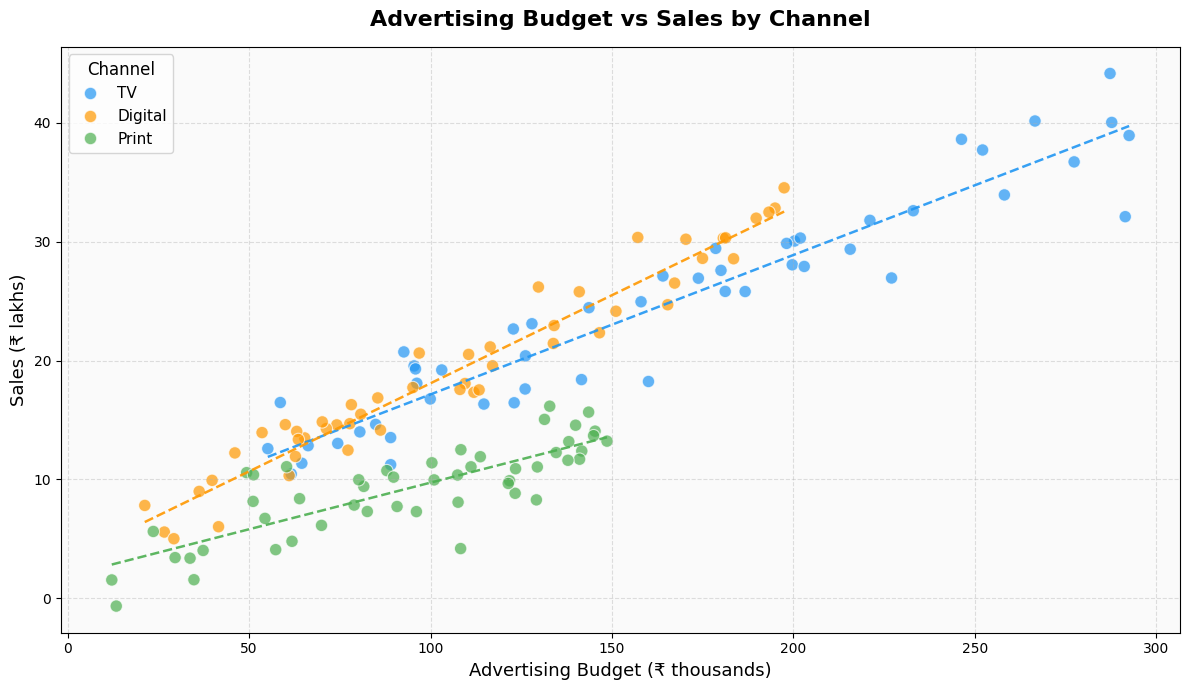

In [10]:
# Question 10 — Scatter Plot to Show Relationship Between Two Variables
# Write your code below

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Generate advertising budget vs sales data with categories
np.random.seed(42)
n = 50

# TV advertising
tv_budget = np.random.uniform(50, 300, n)
tv_sales  = tv_budget * 0.12 + np.random.normal(5, 3, n)

# Digital advertising
digital_budget = np.random.uniform(20, 200, n)
digital_sales  = digital_budget * 0.15 + np.random.normal(3, 2, n)

# Print advertising
print_budget = np.random.uniform(10, 150, n)
print_sales  = print_budget * 0.08 + np.random.normal(2, 2, n)

df_ad = pd.DataFrame({
    "advertising_budget": np.concatenate([tv_budget, digital_budget, print_budget]),
    "sales":             np.concatenate([tv_sales, digital_sales, print_sales]),
    "channel":           ["TV"] * n + ["Digital"] * n + ["Print"] * n
}).round(2)

print("=" * 60)
print("   ADVERTISING BUDGET vs SALES (first 15 rows)")
print("=" * 60)
print(df_ad.head(15).to_string(index=False))

print("\n" + "=" * 60)
print("         SUMMARY BY CHANNEL")
print("=" * 60)
print(df_ad.groupby("channel")[["advertising_budget", "sales"]].describe().round(2))

# Scatter plot with regression line per channel
fig, ax = plt.subplots(figsize=(12, 7))

palette = {"TV": "#2196F3", "Digital": "#FF9800", "Print": "#4CAF50"}

sns.scatterplot(
    data=df_ad,
    x="advertising_budget",
    y="sales",
    hue="channel",
    palette=palette,
    s=80,
    alpha=0.7,
    edgecolor="white",
    linewidth=0.8,
    ax=ax
)

# Add regression lines per channel
for channel, color in palette.items():
    subset = df_ad[df_ad["channel"] == channel]
    z = np.polyfit(subset["advertising_budget"], subset["sales"], 1)
    p = np.poly1d(z)
    x_line = np.linspace(subset["advertising_budget"].min(),
                         subset["advertising_budget"].max(), 100)
    ax.plot(x_line, p(x_line), color=color, linestyle="--",
            linewidth=1.8, alpha=0.9)

ax.set_title("Advertising Budget vs Sales by Channel",
             fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Advertising Budget (₹ thousands)", fontsize=13)
ax.set_ylabel("Sales (₹ lakhs)", fontsize=13)
ax.legend(title="Channel", fontsize=11, title_fontsize=12)
ax.set_facecolor("#FAFAFA")
ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# Expected Output: Scatter plot with regression lines showing budget vs sales

---

<div align="center">

### Declaration

_I hereby declare that the work submitted in this practical assignment is my own and has not been copied from any other source._

| | |
|---|---|
| **Student Name** | **Manthan Sankpal**|
| **PRN** | **125M1H064**|
| **Date** | **11/07/2026**|

---

**Prof. Prakash Ukhalkar**  
Course Teacher - Advanced Data Science Lab [MCA33PE21]

![](https://img.shields.io/badge/MCA33PE21-Advanced%20Data%20Science%20Lab-blue?style=flat-square)
![](https://img.shields.io/badge/Practical%20Assignment-01-green?style=flat-square)

</div>